# 02 · Evaluation

How well each recognition model does, read from the committed `evaluation/results.json` only. Nothing here touches raw data or model weights; `uv run ryuk evaluate lfw` and `uv run ryuk evaluate celeba` compute the numbers. Protocol and thresholds follow the evaluation protocol decision (#9).

Verification on LFW comes first. Then the watchlist rehearsal on CelebA: each model's threshold frozen on the validation draw, the test draw scored once at it, and the model the live monitor starts with.

In [1]:
%matplotlib inline
from pathlib import Path

from IPython.display import Markdown, display

from ryuk.evaluation.figures import lfw_roc, openset_curves
from ryuk.evaluation.names import model_name
from ryuk.evaluation.results import Results
from ryuk.evaluation.tables import lfw_markdown, openset_markdown, openset_table

here = Path.cwd().resolve()
root = next(p for p in (here, *here.parents) if (p / "evaluation" / "results.json").is_file())
results = Results.model_validate_json((root / "evaluation" / "results.json").read_bytes())
verification = results.verification
identification = results.identification
if identification is None:
    raise RuntimeError("no CelebA results: run `uv run ryuk evaluate celeba`")
for name, provenance in (
    ("LFW", verification.provenance),
    ("CelebA", identification.provenance),
):
    print(
        f"{name:7} commit {provenance.commit[:12]}{' (dirty)' if provenance.dirty else ''}, "
        f"{provenance.generated_at:%Y-%m-%d %H:%M} UTC, {provenance.machine}"
    )

LFW     commit 32b79bbc8bb3, 2026-09-25 18:29 UTC, macOS-27.0-arm64-arm-64bit (arm64)
CelebA  commit fb677d3223fb, 2026-09-25 21:46 UTC, macOS-27.0-arm64-arm-64bit (arm64)


## Verification on LFW

LFW View 2 (`pairs.txt`): 6,000 pairs in 10 folds of 300 matched and 300 mismatched. Each image goes through YuNet, the centre-most usable face, a crop and the model. The score is the cosine of the two L2-normalised embeddings. The threshold for each fold is the best on the other nine, over InsightFace's grid, which is the OpenCV zoo / InsightFace recipe the published figures use. Accuracy is the mean over folds, ± the standard error LFW defines (fold standard deviation over √10). Published figures are quoted as their sources give them: FaceNet's ± 0.25 is a standard deviation across folds, not a standard error. AUC and TAR at FAR come from all scored pairs pooled, accepting a pair at or above a threshold, as the live monitor does.

A model more than 0.5 points from its published figure is flagged ⚑. That is a pipeline bug to find, not a result, and it makes the model ineligible to be the first active one.

**Table 1 · Verification on LFW**

In [2]:
display(Markdown(lfw_markdown(verification)))

| Model | Embedding size | Published LFW | Our LFW (± SE) | AUC | TAR @ FAR 1% | TAR @ FAR 0.1% (indicative) |
|---|---:|---:|---:|---:|---:|---:|
| SFace | 128 | 99.40 | 99.38 ± 0.12 | 0.9977 | 99.33 | 98.35 |
| ArcFace (CoreML) | 512 | 99.83 | 99.78 ± 0.08 | 0.9990 | 99.70 | 99.63 |
| FaceNet | 512 | 99.65 | 99.36 ± 0.11 | 0.9987 | 99.36 | 97.94 |

LFW View 2, 5,917 of 6,000 pairs scored, in 10 folds, threshold per fold chosen on the other nine. Accuracy and TAR in percent.

58 images had no usable face, so 83 pairs using them are not scored; the published recipes score every pair. Counting each unscored pair as an error: SFace 98.00, ArcFace (CoreML) 98.40, FaceNet 97.98.

ArcFace (CoreML): The buffalo_l pack's figure. The same README's row for the standalone R50 WebFace600K model says 99.80.

FaceNet: 99.65 ± 0.25, measured on MTCNN crops with a margin of 32 and flipped-image averaging. Ryuk uses a YuNet crop and no flip, so a small shortfall is expected.

SFace int8 is not a row. On macOS-27.0-arm64-arm-64bit (arm64) it scores 99.12 ± 0.13, takes 11.4 ms per face against fp32's 4.1 ms, and its embeddings drift from fp32's (cosine 0.971 on average, 0.930 at worst, over 7,643 faces). It is built for memory-constrained, integer-accelerated hardware this machine is not. crimdet shipped int8; Ryuk does not. The block-quantised int8bq variant does not load on OpenCV 5's default engine at all (#7).

**Figure 1 · LFW View 2 ROC.** True accept rate against false accept rate for every model, on a log FAR axis. The curves start at FAR 10⁻⁴, since 3,000 negative pairs cannot resolve anything smaller.

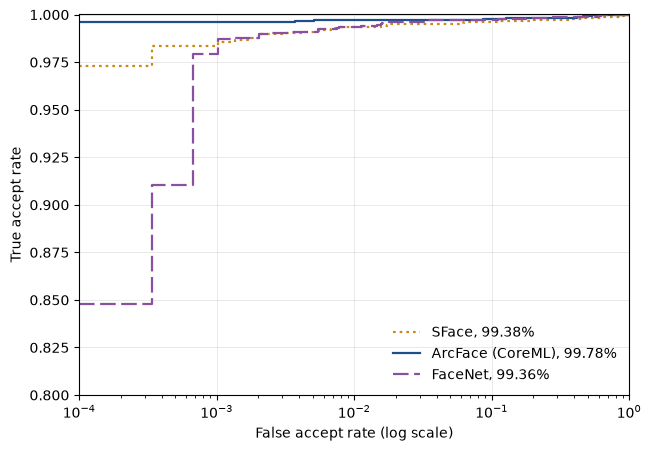

In [3]:
lfw_roc(verification)

## Pipeline choices on View 1

Choices are made on View 1 (`pairsDevTrain` for the threshold, `pairsDevTest` for accuracy), never on View 2. The one choice so far is FaceNet's crop: YuNet's five-point alignment resized to 160, or the YuNet box widened by a margin as facenet-pytorch does, 14 pixels (its default) or 32 (the margin FaceNet's published figure used). Only the winner is scored on View 2, with one exception on record. FaceNet's first View 2 run used margin 14, View 1's choice at the time (five-point scored 98.17 on View 1), and read 99.12, flagged against the published figure. Margin 32 was then added as a candidate, won on View 1 and was scored on View 2, so FaceNet's View 2 has been scored twice (PR #35).

In [4]:
rows = [
    "| Network | Crop | Threshold | DevTest accuracy | Chosen |",
    "|---|---|---:|---:|:---:|",
]
for t in verification.view_1:
    chosen = "✓" if t.chosen else ""
    rows.append(
        f"| {t.network} | {t.crop} | {t.threshold:.3f} | {t.accuracy * 100:.2f} | {chosen} |"
    )
display(Markdown("\n".join(rows)))

| Network | Crop | Threshold | DevTest accuracy | Chosen |
|---|---|---:|---:|:---:|
| facenet | five-point | 0.410 | 98.17 |  |
| facenet | box-margin-14 | 0.430 | 98.78 |  |
| facenet | box-margin-32 | 0.470 | 99.29 | ✓ |

## Per-fold detail

In [5]:
for model in verification.models:
    folds = ", ".join(f"{f.accuracy * 100:.2f}" for f in model.folds)
    print(f"{model_name(model.model):18} {model.crop:14} folds: {folds}")
print(
    f"\n{len(verification.excluded_images)} images without a usable face:",
    ", ".join(verification.excluded_images) or "none",
)

SFace              five-point     folds: 99.49, 99.83, 99.66, 99.15, 98.66, 99.66, 98.99, 99.49, 99.15, 99.66
ArcFace (CoreML)   five-point     folds: 99.66, 100.00, 100.00, 99.66, 99.50, 100.00, 99.66, 100.00, 99.32, 100.00
FaceNet            box-margin-32  folds: 99.66, 99.49, 98.82, 99.66, 99.16, 99.49, 98.99, 99.66, 98.98, 99.66

58 images without a usable face: Adrian_McPherson/Adrian_McPherson_0001.jpg, Alan_Greenspan/Alan_Greenspan_0001.jpg, Alek_Wek/Alek_Wek_0001.jpg, Allan_Houston/Allan_Houston_0001.jpg, Alvaro_Uribe/Alvaro_Uribe_0014.jpg, Andy_Roddick/Andy_Roddick_0008.jpg, Arminio_Fraga/Arminio_Fraga_0001.jpg, Brandon_Spann/Brandon_Spann_0001.jpg, Chloe_Sevigny/Chloe_Sevigny_0001.jpg, Chung_Mong-hun/Chung_Mong-hun_0001.jpg, Clive_Lloyd/Clive_Lloyd_0001.jpg, Courtney_Love/Courtney_Love_0001.jpg, David_Westerfield/David_Westerfield_0001.jpg, Emanuel_Ginobili/Emanuel_Ginobili_0002.jpg, Fatma_Kusibeh/Fatma_Kusibeh_0001.jpg, Fernando_Henrique_Cardoso/Fernando_Henrique_Cardoso_000

## Watchlist search on CelebA

CelebA's official `valid` and `test` splits share no identities, so each is one draw: the validation draw sets thresholds, the test draw reports results. Images with no usable face are excluded first. From the rest, 500 identities with at least 20 usable images are drawn at random into the gallery, each with 5 enrolled photos and 15 mated probes. Every other identity with a usable image is held out, with up to 10 of its images as non-mated probes. The seed and the identity lists are in the results.

In [6]:
rows = [
    "| Draw | Split | Images | Usable | Gallery candidates | Gallery | Held out "
    "| Mated probes | Non-mated probes |",
    "|---|---|---:|---:|---:|---:|---:|---:|---:|",
]
for d in identification.draws:
    rows.append(
        f"| {d.draw} | `{d.split}` | {d.images:,} | {d.usable_images:,} "
        f"({d.usable_images / d.images:.1%}) | {d.gallery_candidates:,} | {len(d.gallery):,} "
        f"| {len(d.held_out):,} | {d.mated_probes:,} | {d.non_mated_probes:,} |"
    )
display(Markdown("\n".join(rows)))
print(f"draw seed {identification.draws[0].seed}, bootstrap seed {identification.bootstrap.seed}")

| Draw | Split | Images | Usable | Gallery candidates | Gallery | Held out | Mated probes | Non-mated probes |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| validation | `valid` | 19,867 | 19,070 (96.0%) | 584 | 500 | 485 | 7,500 | 3,929 |
| test | `test` | 19,962 | 19,228 (96.3%) | 572 | 500 | 500 | 7,500 | 4,072 |

draw seed 27, bootstrap seed 2000


Each probe's match score against a gallery identity is its cosine to that identity's best enrolled photo. Its top candidate is a match when that score is at or above the model's threshold. TPIR is the share of mated probes matched to their own identity, the misidentification rate the share matched to someone else, and FPIR the share of non-mated probes matched to anyone. Each model's threshold is the lowest that keeps FPIR at or below 1% on the validation draw. It is frozen there, and the test draw is scored once at it.

Intervals are 95% identity-level percentile bootstraps: identities are resampled, never single probes, since one person's probes are not independent. Gallery and held-out identities are resampled separately. Any rate within 1% of 0 or 100% is also checked with Fogliato et al.'s dependence-adjusted Wilson interval.

**Table 2 · Watchlist search on CelebA (test draw)**

In [7]:
display(Markdown(openset_markdown(results)))

|  | SFace | ArcFace (CoreML) ★ | FaceNet |
|:----------------|------------:|------------:|------------:|
| Rank-1 | 98.0 [97.6–98.5] | 98.6 [98.3–99.0] | 96.6 [95.9–97.2] |
| Frozen threshold | 0.498 | 0.342 | 0.709 |
| TPIR | 95.0 [94.2–95.8] | 98.5 [98.1–98.8] | 85.1 [83.5–86.7] |
| FPIR | 0.91 [0.62–1.24] | 0.66 [0.40–0.94] | 1.20 [0.74–1.73] |
| Misidentification | 0.16 [0.05–0.31] | 0.13 [0.04–0.25] | 0.39 [0.24–0.55] |
| TPIR @ FPIR 0.1% (indicative) | 90.0 | 98.4 | 72.9 |
| ms per face | 5.4 | 8.4 | 11.7 |

CelebA test draw: 500 gallery identities with 7,500 mated probes, 500 held-out identities with 4,072 non-mated probes. Each model's threshold was frozen at FPIR 1% on the validation draw. Rates in percent with 95% identity-level bootstrap intervals in brackets (2,000 resamples); every rate but rank-1 is at the frozen threshold.

The 5 rates within 1% of 0 or 100% were also checked with the dependence-adjusted Wilson interval (Fogliato et al.); it agrees with the bootstrap.

★ First active model. ArcFace (CoreML) has the highest test TPIR at its frozen threshold (98.47%) of the 3 eligible models, and no other's interval overlaps it.

**Figure 2 · TPIR against FPIR on the CelebA test draw.** Every model's curve on a log FPIR axis, which starts at one false alarm's worth. The marker is each model's frozen threshold: where the validation draw put it, not where the test draw would have.

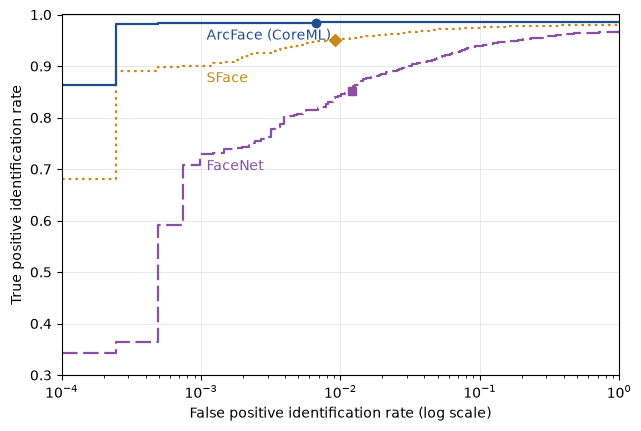

In [8]:
openset_curves(identification)

## The validation draw

Where each threshold was frozen. FPIR at the threshold is at most 1% here by construction; the test draw shows how well the threshold carried over.

In [9]:
display(Markdown(openset_table(results, "validation")))

|  | SFace | ArcFace (CoreML) ★ | FaceNet |
|:----------------|------------:|------------:|------------:|
| Rank-1 | 97.7 [97.0–98.3] | 98.3 [97.7–98.8] | 96.2 [95.3–96.9] |
| Frozen threshold | 0.498 | 0.342 | 0.709 |
| TPIR | 94.8 [93.9–95.6] | 98.2 [97.5–98.7] | 84.5 [82.8–86.1] |
| FPIR | 0.99 [0.66–1.36] | 0.99 [0.53–1.68] | 0.99 [0.60–1.49] |
| Misidentification | 0.17 [0.08–0.28] | 0.12 [0.04–0.21] | 0.23 [0.12–0.36] |
| TPIR @ FPIR 0.1% (indicative) | 83.7 | 80.7 | 65.7 |
| ms per face | 5.4 | 8.4 | 11.7 |

## Thresholds and the first active model

The thresholds block is what the service reads at startup. Each model's threshold is a cut-off under the rule it runs live, which is best photo unless the learning comparison (notebook 03) found a better rule that needs no retraining; eligibility and the first active model are judged under that rule too, so a threshold or test FPIR here can differ from Table 2's best-photo figures. A model can be the first active one only if it reproduces its published LFW figure within 0.5 points on the pairs it could score, keeps test FPIR at or below 2% at its frozen threshold, and takes at most 30 ms per face. Here, as in Table 2, ms per face runs from pixels to top candidate, detection included; the SFace int8 note under Table 1 times the embedding alone. Among those, the highest test TPIR wins, and the faster model wins when intervals overlap.

In [10]:
rows = ["| Model | Rule | Threshold | Target FPIR | Commit | Date |", "|---|---|---:|---:|---|---|"]
for t in results.thresholds:
    rows.append(
        f"| {model_name(t.model)} | {t.rule} | {t.threshold:.4f} | {t.target_fpir:.0%} "
        f"| `{t.commit[:12]}` | {t.date} |"
    )
display(Markdown("\n".join(rows)))

active = results.first_active_model
if active is None:
    raise RuntimeError("no first active model: run `uv run ryuk evaluate celeba`")
rows = [
    "| Model | LFW gap (points) | Test FPIR | ms per face | Eligible |",
    "|---|---:|---:|---:|:---:|",
]
for c in active.eligibility:
    gap = "n/a" if c.lfw_gap_points is None else f"{c.lfw_gap_points:+.2f}"
    rows.append(
        f"| {model_name(c.model)} | {gap} | {c.test_fpir:.2%} | {c.ms_per_face:.1f} "
        f"| {'✓' if c.eligible else '✗'} |"
    )
display(Markdown("\n".join(rows)))
chosen = "none" if active.model is None else model_name(active.model)
print(f"First active model: {chosen}. {active.reason}")

| Model | Rule | Threshold | Target FPIR | Commit | Date |
|---|---|---:|---:|---|---|
| SFace | mean | 0.4943 | 1% | `dbc08c4e8065` | 2026-09-29 |
| ArcFace (CoreML) | best-photo | 0.3417 | 1% | `fb677d3223fb` | 2026-09-25 |
| FaceNet | mean | 0.6911 | 1% | `dbc08c4e8065` | 2026-09-29 |

| Model | LFW gap (points) | Test FPIR | ms per face | Eligible |
|---|---:|---:|---:|:---:|
| SFace | -0.02 | 0.74% | 5.4 | ✓ |
| ArcFace (CoreML) | -0.05 | 0.66% | 8.4 | ✓ |
| FaceNet | -0.29 | 0.96% | 11.7 | ✓ |

First active model: ArcFace (CoreML). ArcFace (CoreML) has the highest test TPIR at its frozen threshold (98.47%) of the 3 eligible models, and no other's interval overlaps it.
